# Labs 1

## Task1: Generate random numbers
- integer in range [0,5] (using random.integers)
- 100 float random numbers in range [0,5] (using random.uniform)
- 3x3 matrix of floats random number in a range [0,2]
- seed and no seed

no seed

In [97]:
import random

from sympy.stats.sampling.sample_numpy import numpy

rand_int = random.randint(0, 5)

print(rand_int)

rand_float = random.uniform(0, 5)

print(rand_float)

matrix = []
width = 3
height = 3

for x in range(width):
    row = []
    for y in range(height):
        row.append(random.uniform(0, 2))

    matrix.append(row)

print(matrix)

5
4.68327293856247
[[1.296070770493187, 1.2182620113339764, 0.342277296396194], [1.4582535959006984, 0.3268049875238568, 0.7589108835152956], [1.9790467012731905, 1.2799995197081857, 1.1138994875492925]]


with seed

In [98]:
import random
# with seed
random.seed(42)

rand_int = random.randint(0, 5)

print(rand_int)

rand_float = random.uniform(0, 5)

print(rand_float)

matrix = []
width = 3
height = 3

for x in range(width):
    row = []
    for y in range(height):
        row.append(random.uniform(0, 2))

    matrix.append(row)

print(matrix)

5
0.556655340828402
[[1.4831009995196658, 0.48978370760695245, 0.2790758570502878], [0.204990352343015, 1.4813354893353516, 1.0907330674966995], [1.1809850248980793, 0.06356535896356719, 0.1873904797231849]]


with numpy

In [99]:
import numpy.random as rng
import numpy as np

print(rng.randint(0, 5))

print(rng.uniform(0,2, 100))

print(rng.uniform(0, 2, size=(10,10)))

1
[1.53006068 0.36708093 0.53877101 1.76830895 0.09963117 1.81877714
 0.80571591 1.4881643  1.8598918  0.79182611 1.47735475 0.16101375
 1.89474676 0.73483522 0.85549962 1.48424091 1.04333235 0.60048109
 1.44710581 1.78181584 1.14188839 0.17351114 0.56932293 0.50209085
 0.66820359 1.72849727 0.08622253 1.13827438 0.08089094 0.50236941
 1.98276637 1.64559096 0.88399326 0.94136467 1.62316102 1.83543361
 1.76163277 0.3662449  1.84444077 0.31525305 0.61361594 0.81141653
 0.585211   1.90454621 1.47333298 0.7028235  1.98922295 0.6302388
 1.93984985 0.66922364 0.94182744 1.70863233 0.55212374 1.10842736
 1.18099277 1.17667983 1.17199375 0.1379778  1.69348118 0.33221536
 1.32017472 0.93680969 0.13213612 1.82487728 1.16038235 1.66659496
 0.66945677 0.04963423 1.04933624 0.41338132 1.71037936 0.80475021
 0.79127168 0.09173522 0.25279014 0.84618324 0.65437437 0.54606886
 0.20238266 1.99344734 0.7580493  1.31291736 0.2130802  0.06967794
 1.02876721 1.7332318  0.40113797 0.9830388  1.71810271 1.210

## Calculate $\pi$ using Monte Carlo methods
- The are of a quarter unit circle is $\frac{\pi}{4}$
- The are of unit square is $1 \implies \pi =  4 * \frac{S_{quarter circle}}{S_{square}} \approx 4*\frac{points-in-circle}{total-point-in-square}$

In [100]:
def check_if_inside_circle(x,y):
    if (np.power(x,2) + np.power(y,2)) <= 1:
        return True
    else:
        return False

bins = {"In": 0, "Out": 0}
iters = 100000
for _ in range(iters):
    x,y = np.random.uniform(0, 1, size=2)
    if check_if_inside_circle(x,y):
        bins["In"] += 1
    else:
        bins["Out"] += 1

ratio = 4 * np.divide(bins["In"], bins["In"] + bins["Out"])
print(f"PI number comparison for {iters} iters:\n -estimated:\t{ratio:.8f}\n -true:\t{np.pi:.8f}\nDifference: {np.abs(ratio - np.pi):.8f}")

PI number comparison for 1000000 iters:
 -estimated:	3.14390400
 -true:	3.14159265
Difference: 0.00231135


## Task3: Calculate integral using monte carlo
- definee `MC_1dim(lower_bound, upper_bound, func, n_points)`, should return the result and standrd error $\delta_{y}$
- Compute fallowing integral
    - $I=\int_{0}^{\pi} sin(x) dx$
- Verify error with $error = |result - 2|$

In [128]:
def MC_1dim(lower_bound, upper_bound, func, n_points):
    sum = 0
    points = np.random.uniform(lower_bound, upper_bound, size=n_points)
    points_values = []

    # calculating the mean
    y_mean_sum = 0
    for x in range(n_points):
        y = func(x)
        y_mean_sum += y

    y_mean = y_mean_sum / n_points

    # calculating the result
    for x in points:
        y = func(x)
        sum += y

    result = (upper_bound - lower_bound)/n_points * sum

    # calculating the standard deviation
    error_sum = 0
    for x in points:
        error_sum += (func(x) - y_mean) ** 2

    std_error = (1/np.sqrt(n_points)) * np.sqrt( (1/(n_points-1)) * error_sum )

    return result, std_error

points = []

results = []
std_errors = []
abs_errors = []

trap_results = []
std_errors_trap = []
abs_errors_trap = []

range_space = range(3,100000, 1000)

for n_point in range_space:
    points.append(n_point)

# monte carlo methods
for n_points in range_space:
    result, std_error = MC_1dim(lower_bound=0, upper_bound=np.pi, func=np.sin, n_points=n_points)

    results.append(result)
    std_errors.append(std_error)
    abs_errors.append(np.abs(result-2))

# trapezoid method
for n_points in range_space:

    result = numpy.trapezoid()


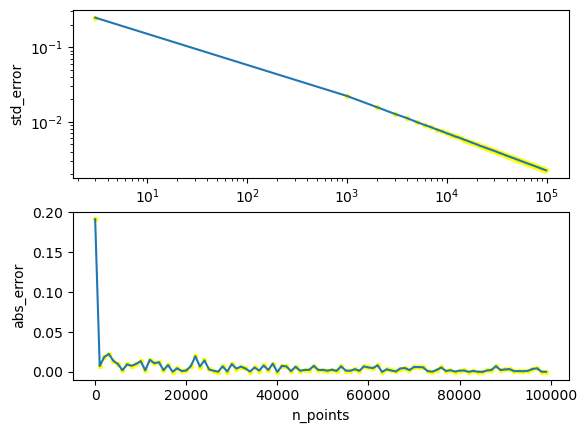

In [129]:
from matplotlib import pyplot as plt

fix, axs = plt.subplots(2,1)

# n_point vs std_error
axs[0].scatter(points,std_errors, marker='.', color='yellow')
axs[0].plot(points, std_errors)
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_xlabel('n_points')
axs[0].set_ylabel('std_error')

# n_points vs abs_error
axs[1].scatter(points, abs_errors, marker='.', color='yellow')
axs[1].plot(points, abs_errors)
# axs[1].set_xscale('log')
# axs[1].set_yscale('log')
axs[1].set_xlabel('n_points')
axs[1].set_ylabel('abs_error')

plt.show()

In [ ]:
ptrapezoid_abs_error = []
for n_points, result in zip(points, results):
    result_trapezoid = numpy.trapezoid()